# Capital Structure

Capital structure describes how a company finances its assets using equity, debt, leases, preferred stock, and other claims. It is the bridge between financial statements, credit analysis, and WACC.

Abbreviations used in this notebook:

- **D**: Debt.
- **E**: Equity.
- **EV**: Enterprise Value.
- **EBITDA**: Earnings Before Interest, Taxes, Depreciation, and Amortization.
- **WACC**: Weighted Average Cost of Capital.

## 1. Intuition

Companies can finance themselves with equity, debt, or a mix of both. Debt is usually cheaper because lenders have senior claims and interest may be tax deductible. Equity is usually more expensive because shareholders bear residual risk. Too much debt can raise bankruptcy risk and reduce flexibility.

Key capital structure concepts:

- **Equity financing**: ownership capital with residual upside and downside.
- **Debt financing**: borrowed capital with contractual interest and principal repayment.
- **Net debt**: debt minus cash.
- **Leverage**: use of debt relative to equity, assets, or cash flow.
- **Interest coverage**: ability to cover interest expense from operating profit.
- **Financial flexibility**: capacity to invest, borrow, or withstand stress.
- **Tax shield**: value created when interest expense reduces taxable income.

## 2. Mathematics

**Net debt:**

$$
\text{Net Debt} = \text{Debt} - \text{Cash}
$$

Where:

- $\text{Debt}$ = interest-bearing borrowings
- $\text{Cash}$ = cash and cash equivalents
- $\text{Net Debt}$ = debt remaining after using available cash to repay borrowings

**Debt to equity:**

$$
\text{Debt / Equity} = \frac{D}{E}
$$

Where:

- $D$ = market value or book value of debt, depending on the analysis
- $E$ = market value or book value of equity, depending on the analysis
- $\text{Debt / Equity}$ = leverage relative to shareholder capital

**Debt to enterprise value:**

$$
\text{Debt / EV} = \frac{D}{D + E}
$$

Where:

- $D$ = debt value
- $E$ = equity value
- $EV$ = enterprise value, approximated here as debt plus equity
- $\text{Debt / EV}$ = share of firm value financed by debt

**Net debt to EBITDA:**

$$
\text{Net Debt / EBITDA} = \frac{\text{Debt} - \text{Cash}}{EBITDA}
$$

Where:

- $\text{Debt}$ = interest-bearing borrowings
- $\text{Cash}$ = cash and cash equivalents
- $EBITDA$ = earnings before interest, taxes, depreciation, and amortization
- $\text{Net Debt / EBITDA}$ = leverage relative to operating cash earnings proxy

**Interest coverage:**

$$
\text{Interest Coverage} = \frac{EBIT}{\text{Interest Expense}}
$$

Where:

- $EBIT$ = earnings before interest and taxes
- $\text{Interest Expense}$ = cost of debt recognized during the period
- $\text{Interest Coverage}$ = ability to pay interest from operating profit

**After-tax cost of debt:**

$$
r_d(1 - T) = \text{Pre-tax Cost of Debt} \times (1 - \text{Tax Rate})
$$

Where:

- $r_d$ = pre-tax cost of debt
- $T$ = corporate tax rate
- $r_d(1 - T)$ = after-tax cost of debt after the interest tax shield


## 3. Implementation

We will calculate a simple capital structure snapshot and show how debt and equity weights feed into WACC.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [8]:
market_cap = 280_000
debt = 42_000
cash = 11_500
ebitda = 23_000
ebit = 18_500
interest_expense = 1_600
pre_tax_cost_of_debt = 0.045
cost_of_equity = 0.075
tax_rate = 0.22

net_debt = debt - cash
enterprise_value = market_cap + net_debt
debt_weight = debt / (debt + market_cap)
equity_weight = market_cap / (debt + market_cap)
after_tax_cost_of_debt = pre_tax_cost_of_debt * (1 - tax_rate)
wacc = equity_weight * cost_of_equity + debt_weight * after_tax_cost_of_debt

capital_structure = pd.DataFrame({
    "metric": [
        "Market cap",
        "Debt",
        "Cash",
        "Net debt",
        "Enterprise value",
        "Debt / equity",
        "Net debt / EBITDA",
        "Interest coverage",
        "After-tax cost of debt",
        "Illustrative WACC",
    ],
    "value": [
        f"CHF {market_cap:,.0f}m",
        f"CHF {debt:,.0f}m",
        f"CHF {cash:,.0f}m",
        f"CHF {net_debt:,.0f}m",
        f"CHF {enterprise_value:,.0f}m",
        f"{debt / market_cap:.2f}x",
        f"{net_debt / ebitda:.2f}x",
        f"{ebit / interest_expense:.1f}x",
        f"{after_tax_cost_of_debt:.2%}",
        f"{wacc:.2%}",
    ],
})

capital_structure

,metric,value
0,Market cap,"CHF 280,000m"
1,Debt,"CHF 42,000m"
2,Cash,"CHF 11,500m"
3,Net debt,"CHF 30,500m"
4,Enterprise value,"CHF 310,500m"
5,Debt / equity,0.15x
6,Net debt / EBITDA,1.33x
7,Interest coverage,11.6x
8,After-tax cost of debt,3.51%
9,Illustrative WACC,6.98%


## 4. Visualization

Capital structure is often shown as a financing mix: how much of the company is funded by debt versus equity.

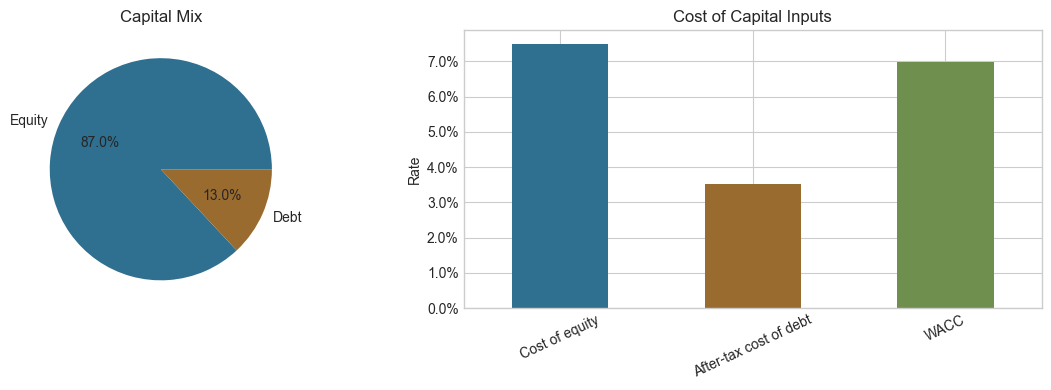

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [market_cap, debt],
    labels=["Equity", "Debt"],
    autopct="%1.1f%%",
    colors=["#2f6f8f", "#9a6b2f"],
)
axes[0].set_title("Capital Mix")

pd.Series({
    "Cost of equity": cost_of_equity,
    "After-tax cost of debt": after_tax_cost_of_debt,
    "WACC": wacc,
}).plot(kind="bar", ax=axes[1], color=["#2f6f8f", "#9a6b2f", "#6f8f4e"])
axes[1].set_title("Cost of Capital Inputs")
axes[1].set_ylabel("Rate")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 5. Application

Capital structure affects valuation, credit risk, and strategic flexibility. Analysts compare leverage ratios against peers, rating guidance, cash-flow stability, and management's target balance sheet.

## 6. Reflection

- Debt can lower WACC through tax shields, but too much debt increases risk.
- Net debt is often more informative than gross debt because cash can repay debt.
- Interest coverage measures debt service capacity.
- Capital structure weights are a key input to WACC.

Questions to answer after running the notebook:

1. Why is debt usually cheaper than equity?
2. Why can too much debt reduce firm value?
3. Why does cash reduce net debt?
4. How does capital structure connect to WACC?